# Clase 13 — Comparar modelos con gráficas

En la Clase 12 entrenamos un solo modelo (KNN) sobre nuestro dataset de frutas inventado. En Módulo 2 (Clase 8) ya vimos que **ningún algoritmo es siempre el mejor**: conviene entrenar más de uno y comparar con evidencia, no por intuición.

Hoy repetimos ese ejercicio, pero con nuestros propios datos y con un tema nuevo y divertido: clasificar **animales** en `domestico` o `salvaje` según su peso y velocidad.

**Objetivos de la clase:**
- Armar un segundo dataset de prueba con pandas.
- Entrenar y comparar 3 modelos: KNN, árbol de decisión y regresión logística.
- Graficar un bar chart comparando accuracy, precision, recall y f1 (igual que en Módulo 2).
- Graficar las 3 matrices de confusión, una al lado de la otra.


---
## 1. Un nuevo dataset de prueba: animales

`peso_kg` y `velocidad_kmh` para 60 animales inventados, etiquetados como `domestico` o `salvaje`.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(7)
n_por_clase = 30

domesticos = pd.DataFrame({
    "peso_kg": np.random.normal(loc=26, scale=11, size=n_por_clase),
    "velocidad_kmh": np.random.normal(loc=23, scale=9, size=n_por_clase),
    "clase": "domestico",
})

salvajes = pd.DataFrame({
    "peso_kg": np.random.normal(loc=38, scale=13, size=n_por_clase),
    "velocidad_kmh": np.random.normal(loc=33, scale=10, size=n_por_clase),
    "clase": "salvaje",
})

animales = pd.concat([domesticos, salvajes], ignore_index=True)
animales["peso_kg"] = animales["peso_kg"].clip(lower=1)
animales["velocidad_kmh"] = animales["velocidad_kmh"].clip(lower=1)

print("Forma del dataset:", animales.shape)
animales.groupby("clase")[["peso_kg", "velocidad_kmh"]].mean().round(1)


Forma del dataset: (60, 3)


,peso_kg,velocidad_kmh
clase,,
domestico,25.2,22.9
salvaje,38.4,34.7


---
## 2. Entrenar 3 modelos con el mismo split

Igual que en Módulo 2: todos los modelos reciben el mismo train/test, para que la comparación sea justa.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X = animales[["peso_kg", "velocidad_kmh"]]
y = animales["clase"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

modelos = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Árbol de decisión": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Regresión logística": LogisticRegression(random_state=42),
}

resultados = []
predicciones = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)
    predicciones[nombre] = y_pred

    resultados.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label="salvaje"),
        "recall": recall_score(y_test, y_pred, pos_label="salvaje"),
        "f1": f1_score(y_test, y_pred, pos_label="salvaje"),
    })

df_resultados = pd.DataFrame(resultados).set_index("modelo")
df_resultados.round(3)


,accuracy,precision,recall,f1
modelo,,,,
KNN,0.800,0.833,0.714,0.769
Árbol de decisión,0.800,0.700,1.000,0.824
Regresión logística,0.867,0.857,0.857,0.857


---
## 3. Comparar con un bar chart

Una tabla de números cuesta leerla rápido. Un bar chart, como el que usamos en Módulo 2, lo resuelve de un vistazo.


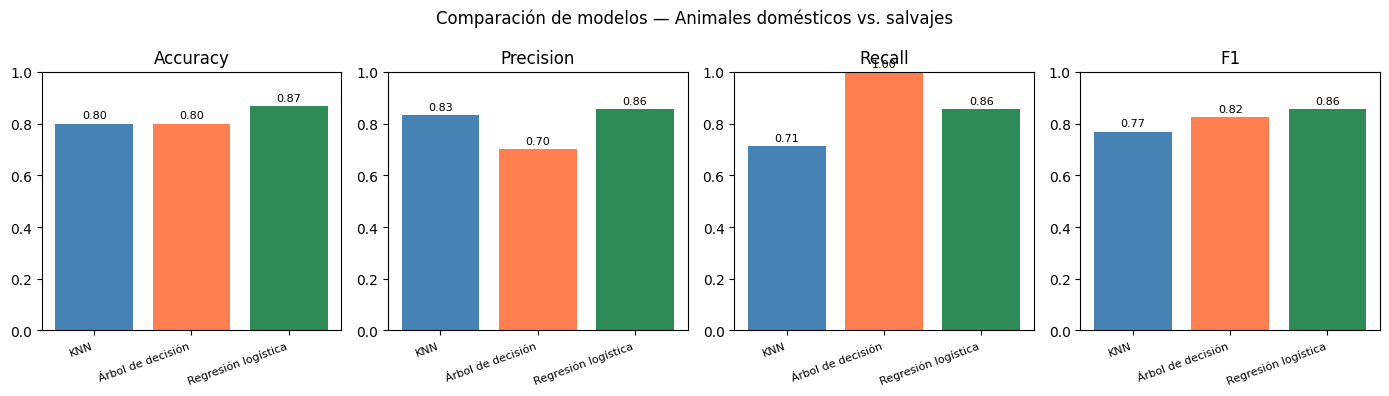

In [12]:
metricas = ["accuracy", "precision", "recall", "f1"]

fig, axes = plt.subplots(1, len(metricas), figsize=(14, 4))

for ax, metrica in zip(axes, metricas):
    valores = df_resultados[metrica]
    posiciones = range(len(valores))
    bars = ax.bar(posiciones, valores.values, color=["steelblue", "coral", "seagreen"])
    ax.set_title(metrica.capitalize())
    ax.set_ylim(0, 1)
    ax.set_xticks(posiciones)
    ax.set_xticklabels(valores.index, rotation=20, ha="right", fontsize=8)
    for bar, val in zip(bars, valores.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{val:.2f}", ha="center", fontsize=8)

plt.suptitle("Comparación de modelos — Animales domésticos vs. salvajes")
plt.tight_layout()

plt.show()

---
## 4. Las 3 matrices de confusión, lado a lado

Dos modelos pueden tener el mismo accuracy y cometer errores muy distintos. La matriz de confusión de cada uno lo muestra.


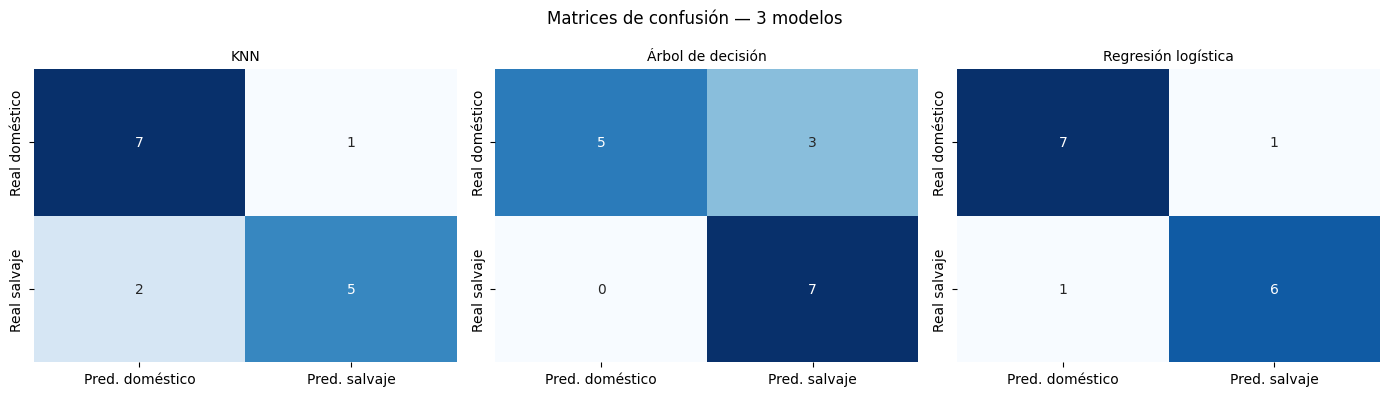

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (nombre, y_pred) in zip(axes, predicciones.items()):
    cm = confusion_matrix(y_test, y_pred, labels=["domestico", "salvaje"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Pred. doméstico", "Pred. salvaje"],
        yticklabels=["Real doméstico", "Real salvaje"],
        ax=ax, cbar=False,
    )
    ax.set_title(nombre, fontsize=10)

plt.suptitle("Matrices de confusión — 3 modelos")
plt.tight_layout()
plt.show()


---
## 📝 Actividad — Elegir el mejor modelo con criterio

**Consigna:**
- Mirando `df_resultados` y las matrices de confusión de arriba, elegí cuál de los 3 modelos usarías.
- Completá el código para mostrar cuál tuvo el `f1` más alto (pista: `.idxmax()`).
- En una celda markdown (podés agregar una nueva o responder en un `print`), justificá tu elección en 2-3 líneas.


In [10]:
# ACTIVIDAD: elegir el mejor modelo con criterio
# TODO: encontrar el modelo con mejor f1
mejor_modelo = df_resultados["f1"].idxmax()
mejor_f1 = df_resultados.loc[mejor_modelo, "f1"]

print(f"Mejor modelo según f1: {mejor_modelo} (f1 = {mejor_f1:.3f})")
print()
print("Justificación: elegimos el modelo con mejor equilibrio entre precision y")
print("recall para la clase 'salvaje', que es la que más nos importa acertar bien.")


Mejor modelo según f1: Regresión logística (f1 = 0.857)

Justificación: elegimos el modelo con mejor equilibrio entre precision y
recall para la clase 'salvaje', que es la que más nos importa acertar bien.


---
## ✅ Resumen

| Herramienta | Qué resuelve |
|---|---|
| `pd.concat([...])`, `.clip(...)` | Armar y limpiar un dataset de juguete |
| Mismo `train_test_split` para 3 modelos | Comparación justa |
| `ax.bar(...)` por métrica | Comparar accuracy/precision/recall/f1 de un vistazo |
| `sns.heatmap` x3 en subplots | Comparar errores de cada modelo, no solo el número final |
| `df_resultados["f1"].idxmax()` | Elegir un modelo con criterio, no a ojo |

**Lo que construiste hoy:**
- un segundo dataset de juguete (animales domésticos vs. salvajes),
- 3 modelos entrenados y comparados con gráficos, igual que en Módulo 2,
- una elección de modelo justificada con evidencia.

**Lo que viene:**
- **Clase 14**: cerramos el módulo con un proyecto divertido que junta todo: tu propio dataset, tu propio modelo y una frontera de decisión para visualizar cómo "piensa" el clasificador.
